<a href="https://colab.research.google.com/github/AntonyJohny/Innomatics_Research_Labs/blob/main/IN126001202_NLP%20/Task_2/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download necessary NLP resources
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [19]:
# Alternative: Run this cell if you don't have the CSV file uploaded
import pandas as pd
url = 'https://raw.githubusercontent.com/Ankit152/IMDB-Sentiment-Analysis/master/IMDB-Dataset.csv'
df = pd.read_csv(url)
print("Dataset loaded successfully from URL!")

Dataset loaded successfully from URL!


In [20]:
import nltk
# Download these three to cover all your bases for this assignment
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')  # This is the one currently missing!
def preprocess_text(text):
    # 1. Lowercasing
    text = text.lower()

    # 2. Removing HTML tags, URLs and Special Characters
    text = re.sub(r'<.*?>', '', text) # Remove HTML
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'[^\w\s]', '', text)

    # 3. Tokenization
    tokens = nltk.word_tokenize(text)

    # 4. Removing Stopwords & Stemming
    stop_words = set(stopwords.words('english'))
    ps = PorterStemmer()

    cleaned_tokens = [ps.stem(w) for w in tokens if w not in stop_words]

    return " ".join(cleaned_tokens)

# Apply preprocessing (This might take a minute depending on dataset size)
print("Preprocessing text... please wait.")
df['cleaned_review'] = df['review'].apply(preprocess_text)
print("Preprocessing Complete!")
df[['review', 'cleaned_review']].head()

Preprocessing text... please wait.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Preprocessing Complete!


,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one review mention watch 1 oz episod youll hoo...
1,A wonderful little production. <br /><br />The...,wonder littl product film techniqu unassum old...
2,I thought this was a wonderful way to spend ti...,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,basic there famili littl boy jake think there ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visual stun film...


In [21]:
# Train-Test Split
X = df['cleaned_review']
y = df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 2. Bag of Words (CountVectorizer)
bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [22]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier()
}

# Training and testing on TF-IDF features
print("--- EVALUATION USING TF-IDF ---")
results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\nModel: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

--- EVALUATION USING TF-IDF ---

Model: Logistic Regression
Accuracy: 0.8854
              precision    recall  f1-score   support

    negative       0.90      0.87      0.88      4961
    positive       0.87      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


Model: Naive Bayes
Accuracy: 0.8492
              precision    recall  f1-score   support

    negative       0.85      0.84      0.85      4961
    positive       0.85      0.86      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000


Model: Decision Tree
Accuracy: 0.7129
              precision    recall  f1-score   support

    negative       0.71      0.71      0.71      4961
    positive       0.72      0.71      0.71      5039

    accuracy                 

/tmp/ipykernel_643/2599001561.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')


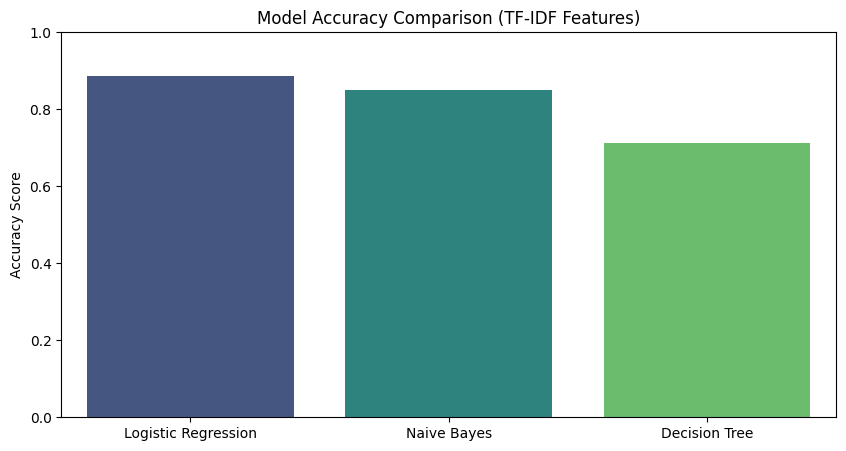

In [23]:
# Plotting the results
plt.figure(figsize=(10, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.title('Model Accuracy Comparison (TF-IDF Features)')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1)
plt.show()